# IMPORT

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import time
from memory_profiler import memory_usage

c:\Users\ARRF\Desktop\Maruthi\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SEED

In [2]:
# Set a seed value
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)

# CUDA

In [3]:
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

True
Using device: cuda



# READ TSP FILE

In [4]:
def read_tsp_file(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    city_coords = []
    for line in lines:
        if line.startswith('EOF'):
            break
        if line[0].isdigit():
            _, x, y = line.strip().split()
            city_coords.append((float(x), float(y)))
    
    n = len(city_coords)
    distance_matrix = torch.zeros((n, n), device=device)
    for i in range(n):
        for j in range(n):
            if i != j:
                distance = math.sqrt((city_coords[i][0] - city_coords[j][0])**2 + (city_coords[i][1] - city_coords[j][1])**2)
                distance_matrix[i][j] = distance
    
    return distance_matrix, city_coords

# PLOT PATH

In [5]:
def plot_tsp_path(city_coords, path):
    x = [coord[0] for coord in city_coords]
    y = [coord[1] for coord in city_coords]
    
    plt.scatter(x, y, c='blue')
    for i in range(len(path) - 1):
        plt.plot([x[path[i]], x[path[i+1]]], [y[path[i]], y[path[i+1]]], c='red')
    plt.plot([x[path[-1]], x[path[0]]], [y[path[-1]], y[path[0]]], c='red')
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('TSP Path with DFS')
    plt.show()

# TOTAL DISTANCE

In [6]:
def total_distance(path, distance_matrix):
    distance = 0
    for i in range(len(path) - 1):
        distance += distance_matrix[path[i]][path[i+1]]
    distance += distance_matrix[path[-1]][path[0]]
    return distance

# DFS

In [7]:
def dfs(distance_matrix,max_iterations):
    n = distance_matrix.shape[0]
    start_city = 0
    stack = [(start_city, [start_city], 0)]  # (current_city, path_taken, total_distance)
    min_cost = float('inf')
    best_path = None
    iterations = 0
    
    while stack and iterations < max_iterations:
        current_city, path, distance = stack.pop()
        
        if len(path) == n:
            total_distance = distance + distance_matrix[current_city][start_city].item()
            if total_distance < min_cost:
                min_cost = total_distance
                best_path = path + [start_city]
            continue
        
        for next_city in range(n):
            if next_city not in path:
                new_distance = distance + distance_matrix[current_city][next_city].item()
                new_path = path + [next_city]
                stack.append((next_city, new_path, new_distance))
        iterations+=1
    
    return min_cost, best_path


# DS1

Optimal Cost: 1362.4869688749313
Optimal Path: [0, 130, 129, 128, 127, 126, 125, 124, 123, 122, 121, 120, 119, 118, 117, 116, 115, 114, 113, 112, 111, 110, 109, 108, 107, 106, 105, 104, 103, 102, 101, 100, 99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82, 81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 3, 2, 1, 6, 5, 4, 0]
Execution Time: 1.4693279266357422 seconds
Memory Usage: 1386.5078125 MiB


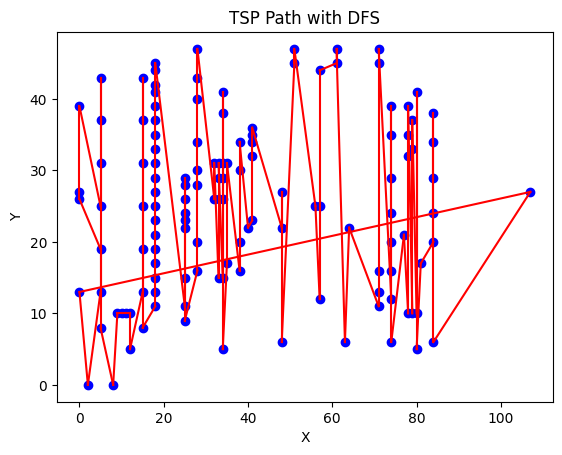

In [17]:
filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS1//DS1.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = dfs(distance_matrix, max_iterations=1000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)

# DS2

Optimal Cost: 35986.11934566498
Optimal Path: [0, 1598, 1597, 1596, 1595, 1594, 1593, 1592, 1591, 1590, 1589, 1588, 1587, 1586, 1585, 1584, 1583, 1582, 1581, 1580, 1579, 1578, 1577, 1576, 1575, 1574, 1573, 1572, 1571, 1570, 1569, 1568, 1567, 1566, 1565, 1564, 1563, 1562, 1561, 1560, 1559, 1558, 1557, 1556, 1555, 1554, 1553, 1552, 1551, 1550, 1549, 1548, 1547, 1546, 1545, 1544, 1543, 1542, 1541, 1540, 1539, 1538, 1537, 1536, 1535, 1534, 1533, 1532, 1531, 1530, 1529, 1528, 1527, 1526, 1525, 1524, 1523, 1522, 1521, 1520, 1519, 1518, 1517, 1516, 1515, 1514, 1513, 1512, 1511, 1510, 1509, 1508, 1507, 1506, 1505, 1504, 1503, 1502, 1501, 1500, 1499, 1498, 1497, 1496, 1495, 1494, 1493, 1492, 1491, 1490, 1489, 1488, 1487, 1486, 1485, 1484, 1483, 1482, 1481, 1480, 1479, 1478, 1477, 1476, 1475, 1474, 1473, 1472, 1471, 1470, 1469, 1468, 1467, 1466, 1465, 1464, 1463, 1462, 1461, 1460, 1459, 1458, 1457, 1456, 1455, 1454, 1453, 1452, 1451, 1450, 1449, 1448, 1447, 1446, 1445, 1444, 1443, 1442, 1441, 14

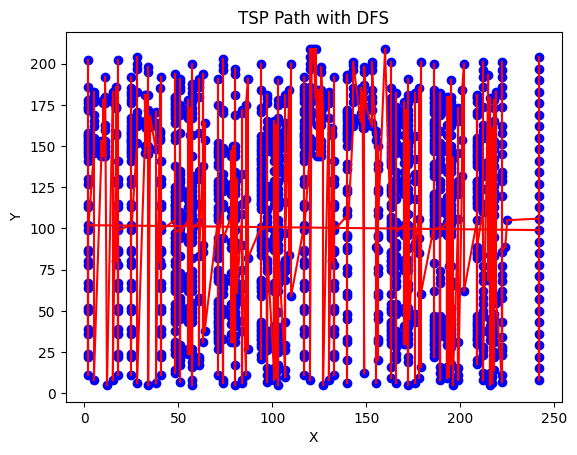

In [20]:
filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS2//DS2.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = dfs(distance_matrix,max_iterations=10000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)

# DS3

Optimal Cost: inf
Optimal Path: None
Execution Time: 727.5614154338837 seconds
Memory Usage: 1412.70703125 MiB


TypeError: object of type 'NoneType' has no len()

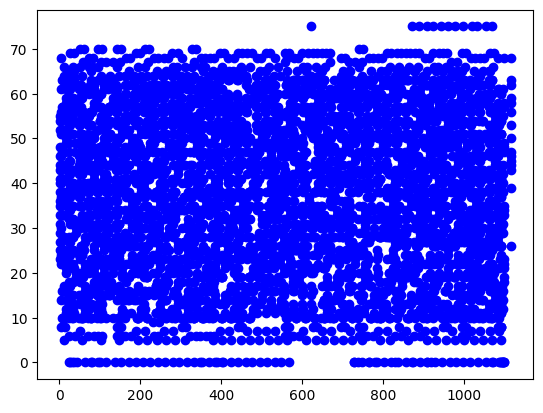

In [8]:
filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS3//DS3.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = dfs(distance_matrix, max_iterations=1000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)